# Stage 8, Part 2: Self-Attention & the Transformer Block

**Goal:** implement self-attention from raw matrix multiplies (similar spirit to Stage 7 Part 1's from-scratch backprop), understand exactly what Q/K/V mean, then assemble a full Transformer block with positional encoding and causal masking.

**Why this matters:** this is the mechanism that replaced RNNs and the mean-pooling approach from Part 1. By the end of this notebook you'll understand every piece of the architecture your GPT capstone (Part 3) is built from.

## 1. The problem, concretely

Recall Part 1's wrap-up limitation: mean pooling averages all word vectors together, so "prize you won" and "won you prize" produce IDENTICAL sequence representations. Word order is completely lost.

What we actually want: for each word, look at every OTHER word in the sequence and decide how much attention to pay to each one, then build a representation that's a WEIGHTED combination (not a flat average) — weighted by relevance, and aware of position.

That's self-attention in one sentence: **for each token, dynamically compute how much every other token (including itself) matters, then combine accordingly.**

## 2. Query, Key, Value — the core idea

This is the part people find confusing on first pass, so build the intuition before any code.

Think of it like a search engine, applied to every token simultaneously:
- **Query (Q):** "what am I looking for?" — a vector representing what THIS token wants to know from the rest of the sequence
- **Key (K):** "what do I contain?" — a vector each token exposes, advertising what kind of information it holds
- **Value (V):** "here's my actual content" — what gets passed along once a token is deemed relevant

For every token, you compare its Query against every other token's Key (via dot product — recall Stage 1: dot product measures alignment) to get a relevance score, turn those scores into weights (via softmax, so they sum to 1), then take a WEIGHTED sum of every token's Value using those weights.

**Critically: Q, K, and V are all just learned linear transformations of the same input embeddings** — three separate weight matrices (`W_q`, `W_k`, `W_v`), each playing the same role `W1` played in Stage 7: a matrix the model learns during training.

## 3. Implement scaled dot-product attention from scratch

Work with a small toy example first — 4 tokens, embedding dimension 8 — so you can inspect every intermediate shape and value directly, before applying this to anything real.

The formula:
```
Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_k)) @ V
```

Guiding question, work through this before coding: `Q @ K.T` produces a matrix of shape (seq_len, seq_len) — what does entry `[i, j]` in that matrix actually represent, in plain language?

Entry [i,j] represent how relevant is token j to token i.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

torch.manual_seed(42)
seq_len = 4 # tokens
d_model = 8 # embedding dimensions

# TODO: create a toy input: x = torch.randn(1, seq_len, d_model)  -- (batch=1, seq_len=4, d_model=8)

x = torch.randn(1, seq_len, d_model)
print(x)


tensor([[[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431,
          -1.6047],
         [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,
           0.7624],
         [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,
           1.6806],
         [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,
           0.8599]]])


In [13]:
# TODO: create three separate nn.Linear(d_model, d_model) layers: W_q, W_k, W_v
# TODO: compute Q = W_q(x), K = W_k(x), V = W_v(x)  -- each shape (1, seq_len, d_model)

W_q = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, d_model)
W_v = nn.Linear(d_model, d_model)

Q = W_q(x)
K = W_k(x)
V = W_v(x)







**Syntax note on the scaling factor:** dividing by `sqrt(d_k)` (where `d_k` is the dimension of K) prevents the dot products from growing too large as dimensionality increases, which would otherwise push softmax into regions with extremely small gradients (a saturation problem, similar in spirit to the sigmoid saturation issues you debugged in Stage 7 Part 1). This is why it's called "SCALED dot-product attention."

In [14]:
# TODO: scores = Q @ K.transpose(-2, -1) / (d_model ** 0.5)   -- shape (1, seq_len, seq_len)
# TODO: attention_weights = F.softmax(scores, dim=-1)          -- softmax over the LAST dimension so each row sums to 1
# TODO: output = attention_weights @ V                          -- shape (1, seq_len, d_model)

# print attention_weights -- inspect the seq_len x seq_len matrix directly


scores = Q @ K.transpose(-2, -1) / (d_model ** 0.5)
attention_weights = F.softmax(scores, dim=-1)  
print(attention_weights)
output = attention_weights @ V  


'''  
                 Keys
             T1     T2     T3     T4
           ┌──────┬──────┬──────┬──────┐
Query T1   │ .1997│ .1608│ .3514│ .2881│
Query T2   │ .1317│ .2530│ .2584│ .3569│
Query T3   │ .2815│ .3417│ .1567│ .2201│
Query T4   │ .1291│ .3134│ .3253│ .2322│
           └──────┴──────┴──────┴──────┘


'''




tensor([[[0.1997, 0.1608, 0.3514, 0.2881],
         [0.1317, 0.2530, 0.2584, 0.3569],
         [0.2815, 0.3417, 0.1567, 0.2201],
         [0.1291, 0.3134, 0.3253, 0.2322]]], grad_fn=<SoftmaxBackward0>)


'  \n                 Keys\n             T1     T2     T3     T4\n           ┌──────┬──────┬──────┬──────┐\nQuery T1   │ .1997│ .1608│ .3514│ .2881│\nQuery T2   │ .1317│ .2530│ .2584│ .3569│\nQuery T3   │ .2815│ .3417│ .1567│ .2201│\nQuery T4   │ .1291│ .3134│ .3253│ .2322│\n           └──────┴──────┴──────┴──────┘\n\n\n'

Guiding question: look at your printed `attention_weights` matrix. Does each ROW sum to 1? Why does that have to be true, given what softmax does and what `dim=-1` means here?

Each row in attention_weights sum to 1. Softmax is applied independently to each row, so the values within each row sum to 1.

## 4. Multi-head attention

A single attention computation can only learn ONE way of relating tokens to each other. Multi-head attention runs SEVERAL attention computations in parallel (each with its own W_q/W_k/W_v), each potentially learning a different kind of relationship (e.g., one head might learn to track subject-verb relationships, another might track nearby words, another something else entirely — these aren't hand-designed, they emerge from training).

**Syntax note:** with `d_model=8` and `n_heads=2`, each head works with dimension `d_model / n_heads = 4`. The heads run independently, then their outputs are concatenated back to `d_model` and passed through one more linear layer.

This is available as a single built-in layer: `nn.MultiheadAttention(embed_dim, num_heads)`. Given you just built single-head attention from scratch, it's fine to use the built-in here rather than re-implementing the multi-head splitting logic by hand — the value of building it once from scratch (Section 3) was understanding the mechanism, not re-deriving it every time, same reasoning as Stage 7 Part 2 switching to PyTorch's CNN layers after your from-scratch network.

In [15]:
# TODO: mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=2, batch_first=True)
# TODO: output, attn_weights = mha(x, x, x)  -- query, key, value all the same input, since this is SELF-attention
# print output.shape -- should match x.shape

mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=2, batch_first=True)
output, attn_weights = mha(x, x, x)
print(x.shape)
print(output.shape)






torch.Size([1, 4, 8])
torch.Size([1, 4, 8])


Guiding question: why does calling `mha(x, x, x)` — passing the SAME tensor as query, key, and value — make this "self"-attention specifically? (What would it mean if query came from one sequence and key/value came from a different sequence? This distinction becomes relevant later for encoder-decoder architectures, even though your GPT capstone won't need it.)

The reason why we pass the same tensor as query, key and value, is so that this is self attention. At each token, we create a Query. We compare that Query against every token's Key to determine how relevant each token is. Then we use those relevance scores to decide how much of each token's Value to retrieve.

## 5. Positional encoding

Notice: nothing in the attention computation above uses token POSITION at all — it's purely based on content (Q/K/V derived from each token's embedding). If you shuffled the input tokens, attention would produce the same set of outputs, just reordered — it has no inherent sense of "first" or "last." This is a real gap, since word order clearly matters for meaning.

**The fix:** add a position-dependent vector to each token's embedding BEFORE attention, so position information is baked directly into what attention operates on. The classic approach (from the original Transformer paper) uses sine and cosine functions at different frequencies:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

You don't need to derive this formula — the important conceptual point is simpler: each position gets a unique, fixed pattern of values, added elementwise to that position's token embedding.

First, give every token its meaning and position. Then, for every token, determine which other tokens are relevant to it, and use those relevance weights to combine information from the other tokens.


                 TOKEN EMBEDDINGS
                       x
                       │
                       │
                       +  positional encoding
                       │
                       ↓
               x_with_pos
                       │
              ┌────────┼────────┐
              ↓        ↓        ↓
             W_Q      W_K      W_V
              ↓        ↓        ↓
              Q        K        V
              │        │
              └───┬────┘
                  │
                  ↓
              Q @ Kᵀ
                  │
                  ↓
               scale
                  │
                  ↓
               softmax
                  │
                  ↓
          attention weights
                  │
                  │
                  └──────────┐
                             ↓
                       weights @ V
                             │
                             ↓
                          OUTPUT

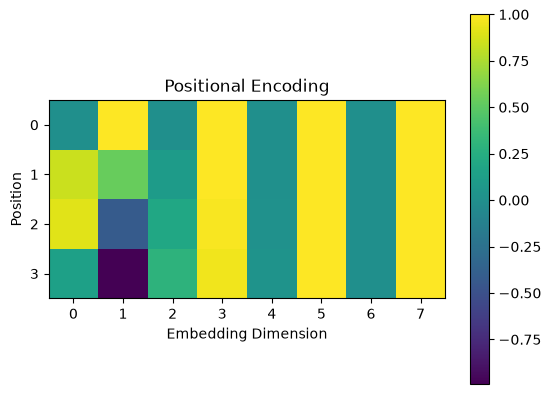

In [16]:
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

# TODO: compute pe = positional_encoding(seq_len, d_model), add it to x: x_with_pos = x + pe
# TODO: plot the positional encoding matrix as a heatmap (plt.imshow) to SEE the pattern -- each row is a unique fingerprint for that position


#position encoding
pe = positional_encoding(seq_len, d_model)
x_with_pos = x + pe



'''
#Create the Query, Key, and Value transformations
W_q = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, d_model)
W_v = nn.Linear(d_model, d_model)

#attention
Q = W_q(x_with_pos) # "What information am I looking for?"
K = W_k(x_with_pos) #"What kind of information do I have that might be useful to another token?"
V = W_v(x_with_pos) #"If you decide I'm relevant, here's the actual information you can retrieve from me."

scores = Q @ K.transpose(-2, -1) / (d_model ** 0.5) #For every token, how relevant is every other token?
attention_weights = F.softmax(scores, dim=-1) #Turn scores into attention weights

#Retrieve information from the Values
output = attention_weights @ V

'''
import matplotlib.pyplot as plt
plt.imshow(pe)
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Positional Encoding")
plt.show()



## 6. Causal masking

For a model that GENERATES text one token at a time (like GPT), a token must only be allowed to attend to itself and EARLIER tokens — never future ones, since at generation time, future tokens don't exist yet. Without this constraint, the model could "cheat" during training by looking ahead at the answer.

**The mechanism:** before the softmax step, set all "future" positions in the attention score matrix to negative infinity. Since `softmax(-inf) = 0`, this makes those positions receive exactly zero attention weight, without changing the math anywhere else.

**Syntax note:** `torch.triu(torch.ones(seq_len, seq_len), diagonal=1)` creates an upper-triangular matrix of 1s (everything ABOVE the diagonal — i.e., every "future" position relative to each row). Multiply this mask by a large negative number and add it to your attention scores before softmax.

In [19]:
# TODO: build the causal mask, print it to see the upper-triangular pattern directly
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
print(mask)

# TODO: apply it: masked_scores = scores + mask * -1e9  (using your scores from Section 3)
# TODO: masked_attention_weights = F.softmax(masked_scores, dim=-1)
# print masked_attention_weights -- confirm every entry in the upper triangle is now ~0


masked_scores = scores + mask * -1e9 
print(scores)
print(masked_scores)
masked_attention_weights = F.softmax(masked_scores, dim=-1)
print(masked_attention_weights)

tensor([[0., 1., 1., 1.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]])
tensor([[[-0.1147, -0.3311,  0.4505,  0.2521],
         [-0.2958,  0.3568,  0.3780,  0.7008],
         [-0.2124, -0.0188, -0.7986, -0.4586],
         [-0.5293,  0.3573,  0.3945,  0.0572]]], grad_fn=<DivBackward0>)
tensor([[[-1.1473e-01, -1.0000e+09, -1.0000e+09, -1.0000e+09],
         [-2.9584e-01,  3.5684e-01, -1.0000e+09, -1.0000e+09],
         [-2.1239e-01, -1.8820e-02, -7.9856e-01, -1.0000e+09],
         [-5.2925e-01,  3.5734e-01,  3.9455e-01,  5.7209e-02]]],
       grad_fn=<AddBackward0>)
tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3424, 0.6576, 0.0000, 0.0000],
         [0.3610, 0.4381, 0.2009, 0.0000],
         [0.1291, 0.3134, 0.3253, 0.2322]]], grad_fn=<SoftmaxBackward0>)


Guiding question: looking at your masked attention weights, what should row 0 (the first token) look like, specifically? How many nonzero values should it have, and why?

The first row should have about three 0's [1,0,0,0] because the first token should only be able to its own token, for example Token \(i\) is allowed to attend to tokens \(j == i\), but not future tokens \(j > i\). and since it is on the same row=col, it is able to see itself.

## 7. Assembling a full Transformer block

A real Transformer block combines everything above with two more standard deep learning ingredients you already know from Stage 7:

- **Residual connections:** add the block's input back to its output (`x + sublayer(x)`) — helps gradients flow through many stacked layers without vanishing, same underlying motivation as why this mattered for very deep networks generally.
- **Layer normalization:** normalizes activations (conceptually related to batch norm from Stage 7 Part 3, but normalizes across the FEATURE dimension per-token rather than across the batch) — stabilizes training.

A full block: `x -> self-attention -> add & norm -> feedforward -> add & norm -> output`

In [20]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=32):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.feedforward = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_output, _ = self.attention(x, x, x, attn_mask=mask)
        x = self.norm1(x + attn_output)     #     -- residual connection, then normalize
        ff_output = self.feedforward(x)
        x = self.norm2(x + ff_output)          #    -- residual connection, then normalize
        return x


In [21]:
# TODO: instantiate a TransformerBlock, run your x_with_pos through it, confirm the output shape matches the input shape

transformer = TransformerBlock(
    d_model=d_model,
    n_heads=2,
    d_ff=32
)

result = transformer(x_with_pos)

print(x_with_pos.shape)
print(result.shape)



torch.Size([1, 4, 8])
torch.Size([1, 4, 8])


## Wrap-up

Write a short summary:
- In your own words, walk through what Q, K, and V each represent, and why the analogy to a search engine helps (or doesn't, if you found a better mental model).
- Why does self-attention solve the word-order problem that Part 1's mean pooling had? Be specific about which piece (attention weighting itself, or positional encoding) is actually responsible for preserving order information — they're solving two different problems.
- Causal masking uses `-inf` before softmax rather than just zeroing out future positions AFTER softmax. Why does the order matter here? (Hint: think about what a row of attention weights needs to do — sum to 1 — and whether zeroing after softmax would preserve that.)

- Query (Q): What information am I looking for? Key (K): What kind of information do I have? Value (V): What information should I actually provide if someone pays attention to me?

-  A token embedding tells the Transformer something about what the token is, while positional encoding gives information about where that token occurs in the sequence. What it is VS where it is.  Attention weights identify how relevant each token is to another token. Self-attention solves the word order problem since part 1 mean pooling was just a flat vector, switching words around like "man bite dog" vs "dog bite man" shared the same representation which is not useful. Having the positional encodings make sentences more meaningful.

- Zeroing after softmax would not perserve the rows summing up to 1. We do it beforehand so we can apply softmax properly.


